# Building and validating the volatility surfaces

This notebook walks through how one day's raw option chain becomes a stored
implied-volatility surface, and how the surfaces were validated. It uses the
project's own code (`src/surface/`), so what you see is what the daily job
runs.

1. **Inputs**: one SPY chain as scraped from Yahoo.
2. **Forwards** from put-call parity, per expiry.
3. **Implied vols** from out-of-the-money mid prices (Black-76).
4. **An SVI smile per expiry**: fit, weighting, outlier handling.
5. **From expiries to a surface**: interpolation in total variance, and the observed/extrapolated mask.
6. **Validation (the backtest of the surfaces)**: SPY's 30-day variance swap against VIX, 2010–2023 and 2026, and the old pipeline against the new one.
7. **Noise floors** of the derived features.
8. **The rejected alternative**: a joint eSSVI fit.

Data come from the local stores under `data/`. Re-running the notebook
re-runs every number below.

In [1]:
import os, sys, math, warnings
from pathlib import Path

# Run from the repository root so `src` and `data/` resolve.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._build.plotting import THEME as T, style_axes, setup_matplotlib
setup_matplotlib()
pd.set_option("display.width", 160, "display.max_columns", 20, "display.precision", 4)

TICKER, DAY, RATE = "SPY", "2026-10-01", 0.042

## 1. Inputs: one day's raw chain

The daily job stores every listed contract with its bid, ask, Yahoo's own
`impliedVolatility`, open interest and the underlying's price at the
snapshot (16:30 ET).

In [2]:
from src.data.storage import load_options_chain

chain = load_options_chain(TICKER, start=DAY, end=DAY)
spot = float(chain["underlying_price"].median())
two_sided = (chain["bid"] > 0) & (chain["ask"] > chain["bid"])
print(f"{TICKER} {DAY}: {len(chain):,} contracts, {chain['expiration'].nunique()} expiries, "
      f"spot {spot:.2f}, two-sided quotes {two_sided.mean():.0%}")
near = chain[(chain["T"].between(25 / 365, 40 / 365))].copy()
near = near.iloc[(near["strike"] - spot).abs().argsort()[:6]].sort_values(["strike", "option_type"])
near[["expiration", "strike", "option_type", "bid", "ask", "implied_volatility_market",
      "open_interest", "T"]]

SPY 2026-10-01: 6,591 contracts, 27 expiries, spot 763.99, two-sided quotes 100%


,expiration,strike,option_type,bid,ask,implied_volatility_market,open_interest,T
4354,2026-10-30,763.0,call,14.05,14.28,0.1578,396.0,0.0795
4369,2026-10-30,763.0,put,10.04,10.08,0.1211,1991.0,0.0795
4387,2026-11-06,764.0,call,15.45,15.74,0.1622,137.0,0.0986
4386,2026-10-30,764.0,call,13.42,13.78,0.1577,762.0,0.0795
4402,2026-10-30,764.0,put,10.40,10.44,0.1195,1802.0,0.0795
4403,2026-11-06,764.0,put,11.73,11.90,0.1226,149.0,0.0986


## 2. Forwards from put-call parity

The textbook forward `S·e^{rT}` ignores dividends (about 1.3% a year for SPY)
and any borrow cost. For each expiry the builder instead reads the forward
off put-call parity, `F = K + (C − P)/D`, using the strikes closest to the
money, and falls back to the carry forward only when parity is unusable.

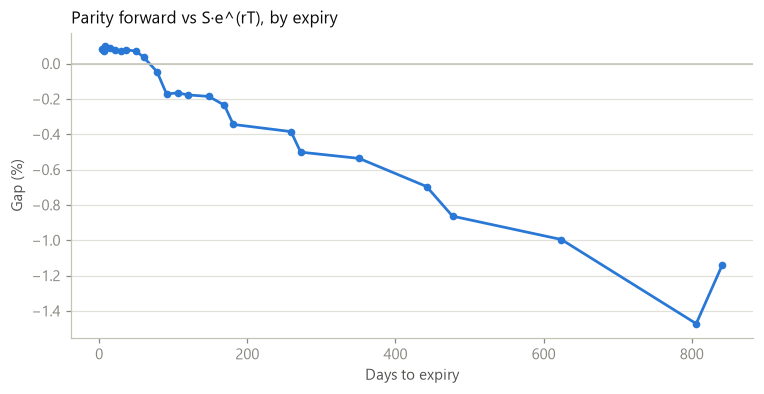

Forwards from parity: 100% of expiries; gap at the longest expiry -1.14% (implied carry 3.70%/yr vs rate 4.2%)


In [3]:
from src.surface.slices import otm_quotes

quotes, forwards = otm_quotes(chain, spot, lambda T: RATE)
fw = pd.DataFrame([{"days": 365 * T, "T": T, "parity_forward": F, "source": src,
                    "carry_forward": spot * math.exp(RATE * T)}
                   for T, (F, D, src) in sorted(forwards.items())])
fw["gap_pct"] = 100 * (fw["parity_forward"] / fw["carry_forward"] - 1)
fw["implied_carry_pct"] = 100 * np.log(fw["parity_forward"] / spot) / fw["T"]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(fw["days"], fw["gap_pct"], color=T.series[0], marker="o", ms=4)
ax.axhline(0, color=T.axis, lw=1)
style_axes(ax, "Parity forward vs S·e^(rT), by expiry", "Days to expiry", "Gap (%)")
plt.show()
print(f"Forwards from parity: {(fw['source'] == 'parity').mean():.0%} of expiries; "
      f"gap at the longest expiry {fw['gap_pct'].iloc[-1]:+.2f}% "
      f"(implied carry {fw['implied_carry_pct'].iloc[-1]:.2f}%/yr vs rate {100 * RATE:.1f}%)")

The gap grows roughly linearly with maturity, which is the dividend yield
compounding. Quoting moneyness against the wrong forward would bias every
call-versus-put comparison, and so every skew feature.

## 3. Implied vols from out-of-the-money mids

The builder inverts Black-76 on each quote's mid, using that expiry's parity
forward. It keeps only out-of-the-money options (puts below the forward,
calls above): in-the-money quotes have wide spreads relative to their time
value, and carry the early-exercise premium of American options.

The original pipeline used Yahoo's `impliedVolatility` instead, which was
the first problem the audit found:

In [4]:
from src.surface.implied_vol import black_implied_vol

c = chain[two_sided & chain["T"].between(20 / 365, 100 / 365)].copy()
T_key = c["T"].round(8)
c["F"] = T_key.map({round(k, 8): v[0] for k, v in forwards.items()})
c["D"] = T_key.map({round(k, 8): v[1] for k, v in forwards.items()})
c = c.dropna(subset=["F"])
c["k"] = np.log(c["strike"] / c["F"])
c = c[c["k"].abs() < 0.15]
mid = 0.5 * (c["bid"] + c["ask"])
is_call = c["option_type"].eq("call").to_numpy()
c["iv_mid"] = black_implied_vol(mid.to_numpy(), c["F"].to_numpy(), c["strike"].to_numpy(),
                                c["T"].to_numpy(), c["D"].to_numpy(), is_call)
c["otm"] = np.where(is_call, c["k"] >= 0, c["k"] < 0)
c["diff_pts"] = 100 * (c["implied_volatility_market"] - c["iv_mid"])
summary = c.groupby(c["otm"].map({True: "out of the money", False: "in the money"}))["diff_pts"] \
           .agg(n="size", median="median", mad=lambda s: s.abs().median())
summary.round(2)

,n,median,mad
otm,,,
in the money,512,2.97,3.60
out of the money,1001,-1.13,1.25


Yahoo's IV differs from IV computed from the same quotes by about a vol point
out of the money and about three in the money. Those differences are as
large as the skew features themselves.

## 4. An SVI smile per expiry

Each expiry gets its own raw-SVI fit to its OTM quotes:

`w(k) = a + b(ρ(k − m) + √((k − m)² + σ²))`, with total variance `w = σ_BS²·T`.

- **Quasi-explicit fitting**: for fixed `(m, σ)` the model is linear in
  `(a, b(1+ρ), b(1−ρ))`. That inner problem is solved exactly under the
  constraints `a ≥ 0` (variance never negative) and wing slopes ≤ 2 (Lee's
  moment bound). An outer search runs over `(m, σ)`.
- **Weights**: residuals are measured in implied-vol units and divided by
  each quote's bid-ask spread in vol terms, so tight quotes count more.
- **Outliers**: one round of rejection; a quote within its own spread is
  never rejected.

The original pipeline pooled every expiry within ±30% of a target tenor into
one fit with a shared time-to-expiry. That was the main source of the noise
seen in the audit.

In [5]:
from src.surface.slices import fit_slices

fits = fit_slices(chain, spot, lambda T: RATE)
tbl = pd.DataFrame([{"expiration": f.expiration, "days": round(365 * f.T), "quotes": f.n_quotes,
                     "outliers": f.n_outliers, "fit_rmse_pts": 100 * f.rmse_iv,
                     "a": f.a, "b": f.b, "rho": f.rho, "m": f.m, "sigma": f.sigma}
                    for f in fits])
print(f"{len(fits)} expiries fitted; median fit error {tbl['fit_rmse_pts'].median():.2f} vol pts")
tbl.round(4)

26 expiries fitted; median fit error 0.33 vol pts


,expiration,days,quotes,outliers,fit_rmse_pts,a,b,rho,m,sigma
0,2026-10-05,4,54,0,0.1730,0.0,0.0138,-1.0000,-0.0499,0.0322
1,2026-10-06,5,62,1,0.1995,0.0,0.0101,-1.0000,-0.0436,0.0433
2,2026-10-07,6,67,0,0.2507,0.0,0.0090,-1.0000,-0.0391,0.0516
3,2026-10-08,7,70,0,0.2595,0.0,0.0108,-1.0000,-0.0424,0.0541
4,2026-10-09,8,82,0,0.3485,0.0,0.0122,-0.9661,-0.0415,0.0544
5,2026-10-16,15,119,0,0.3529,0.0,0.0173,-0.8993,-0.0334,0.0607
6,2026-10-23,22,118,0,0.3548,0.0,0.0209,-0.8324,-0.0227,0.0618
7,2026-10-30,29,201,0,0.3543,0.0,0.0261,-0.8472,-0.0300,0.0749
8,2026-11-06,36,127,1,0.2228,0.0,0.0293,-0.9152,-0.0318,0.0881
9,2026-11-20,50,141,1,0.2517,0.0,0.0371,-0.8903,-0.0351,0.0985


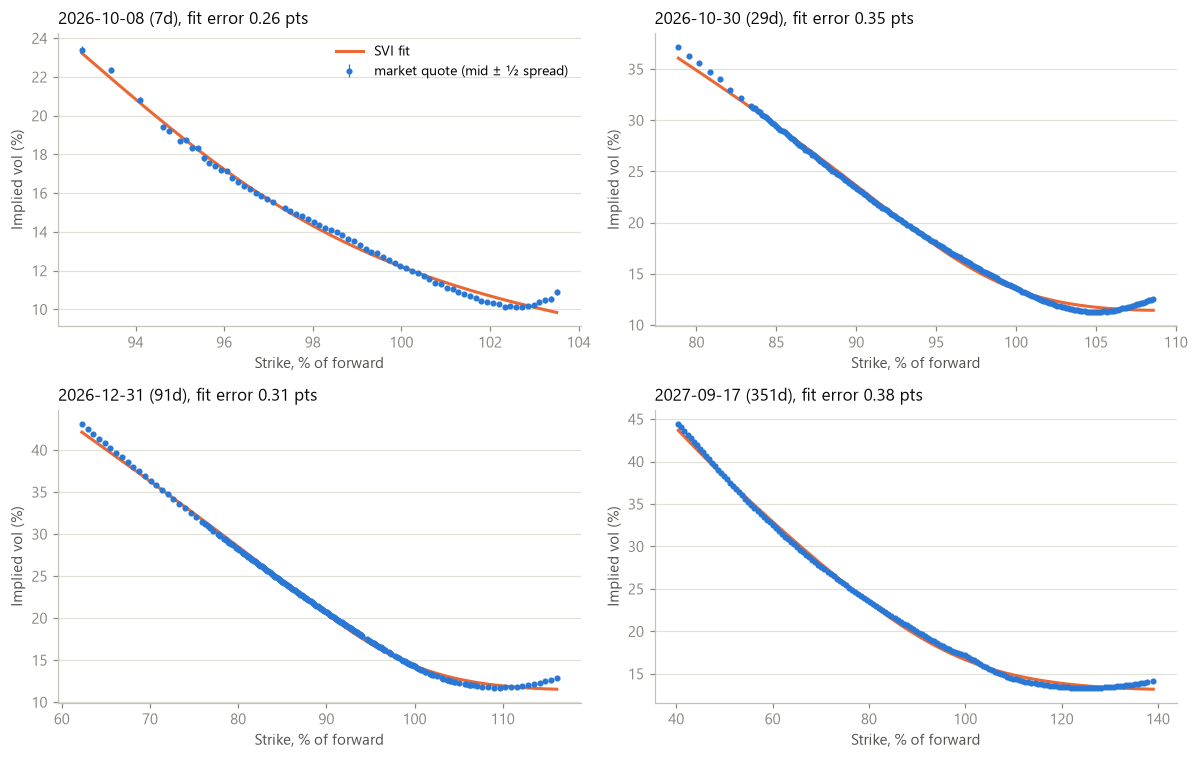

In [6]:
pick = [tbl.iloc[(tbl["days"] - d).abs().argmin()]["expiration"] for d in (7, 30, 91, 365)]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, e in zip(axes.ravel(), pick):
    f = next(s for s in fits if s.expiration == e)
    q = quotes[pd.to_datetime(quotes["expiration"]).dt.strftime("%Y-%m-%d") == e]
    ax.errorbar(100 * np.exp(q["k"]), 100 * q["iv"], yerr=50 * q["spread_iv"].fillna(0),
                fmt="o", ms=3, color=T.series[0], ecolor=T.series[0], elinewidth=0.8,
                label="market quote (mid ± ½ spread)")
    kk = np.linspace(f.k_min, f.k_max, 200)
    ax.plot(100 * np.exp(kk), 100 * f.iv(kk), color=T.series[1], lw=2, label="SVI fit")
    style_axes(ax, f"{e} ({round(365 * f.T)}d), fit error {100 * f.rmse_iv:.2f} pts",
               "Strike, % of forward", "Implied vol (%)")
axes[0, 0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. From expiries to a surface

To get a value at any tenor, total variance is interpolated linearly in time
between the two expiries that bracket it, at fixed forward log-moneyness.
This is the same construction CBOE uses to get VIX's constant 30 days.

Beyond the last quoted strike, each smile continues along its tangent rather
than its SVI wing. On sparse chains the raw wing can explode: one XLF expiry
extrapolated to 230% vol at k = −0.4. Every grid cell is flagged
**observed** only if it lies inside the quoted range of both bracketing
expiries; features never use extrapolated cells.

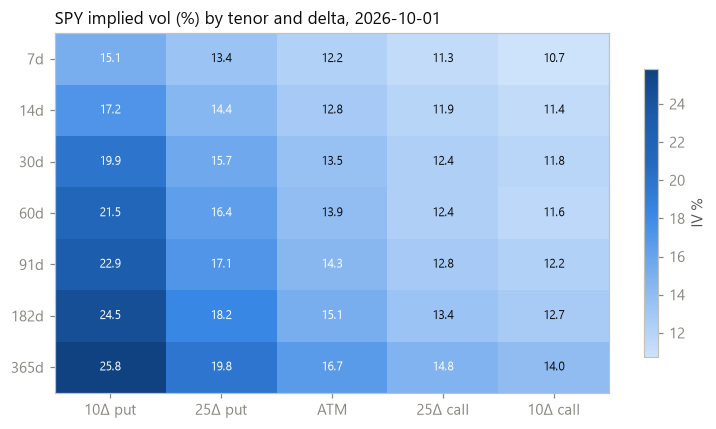

In [7]:
from src.surface.slices import ExpirySurface
from src.dashboard.data import DELTA_COLUMNS
from src.features.surface_features import TENORS_DAYS

surf = ExpirySurface(fits)
grid = pd.DataFrame(index=list(TENORS_DAYS), columns=list(DELTA_COLUMNS), dtype=float)
for name, days in TENORS_DAYS.items():
    Tn = days / 365
    for col, delta in DELTA_COLUMNS.items():
        k = 0.0 if delta == 0 else surf.delta_strike(delta, Tn)
        ok = surf.brackets(Tn) and bool(surf.is_observed(k, Tn))
        grid.loc[name, col] = 100 * float(surf.iv(k, Tn)) if ok else np.nan

fig, ax = plt.subplots(figsize=(7, 4))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("seq", T.sequential)
im = ax.imshow(grid.to_numpy(dtype=float), cmap=cmap, aspect="auto")
ax.set_xticks(range(len(grid.columns)), grid.columns); ax.set_yticks(range(len(grid.index)), grid.index)
for (i, j), v in np.ndenumerate(grid.to_numpy(dtype=float)):
    if np.isfinite(v):
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                color="white" if v > np.nanmedian(grid.to_numpy(dtype=float)) else T.ink)
ax.set_title(f"{TICKER} implied vol (%) by tenor and delta, {DAY}", loc="left", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label="IV %")
plt.tight_layout(); plt.show()

The textbook equity-index shape: puts richer than calls (skew), skew steepest
at short tenors, and vol rising with maturity.

## 6. Validation: SPY's 30-day variance swap against VIX

This is the backtest of the surfaces. VIX is a 30-day variance swap on the
S&P 500, computed by CBOE from SPX options. Rebuilding the same quantity
from our fitted SPY smiles (integrated over each expiry's smile, then
interpolated to 30 days) gives an independent check. Any construction noise
shows up directly as disagreement.

In [8]:
from src.features import load_feature_table
from src.surface.diagnostics import benchmark_against

live = load_feature_table("data/features/surface_features.parquet", tickers=["SPY"])
hist = load_feature_table("data/historical/features/surface_features.parquet", tickers=["SPY"])
rows = {}
for name, f in (("2010–2023 (historical, Kaggle chains)", hist), ("2026 (live, Yahoo chains)", live)):
    s = f.set_index("date")
    rows[name] = benchmark_against(100 * s["vs_30d"], s["mkt_vix"])
pd.DataFrame(rows).T[["n", "level_corr", "change_corr", "mean_diff", "mean_abs_diff"]].round(3)

,n,level_corr,change_corr,mean_diff,mean_abs_diff
"2010–2023 (historical, Kaggle chains)",3488.0,0.997,0.969,-0.204,0.415
"2026 (live, Yahoo chains)",154.0,0.998,0.981,-0.337,0.357


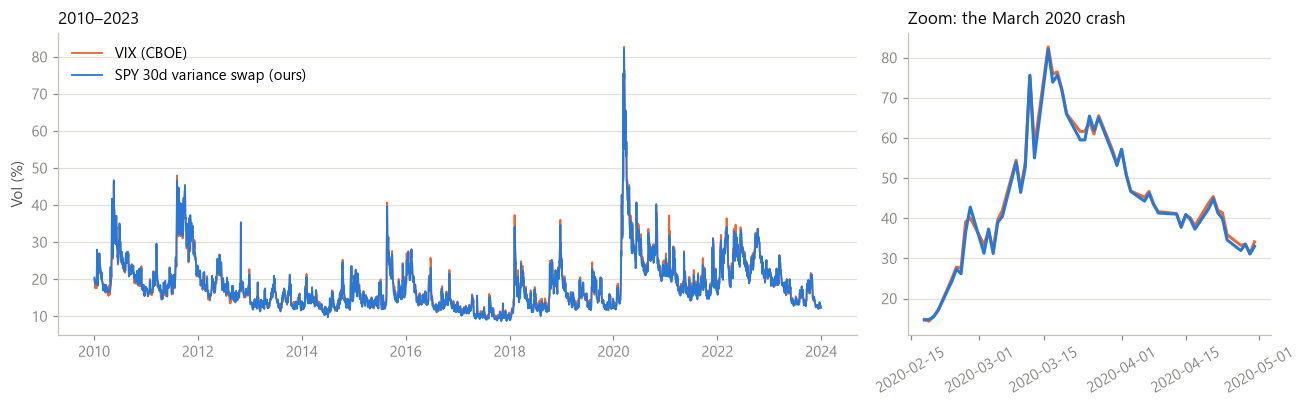

In [9]:
h = hist.set_index("date")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
ax.plot(h.index, h["mkt_vix"], color=T.series[1], lw=1.2, label="VIX (CBOE)")
ax.plot(h.index, 100 * h["vs_30d"], color=T.series[0], lw=1.2, label="SPY 30d variance swap (ours)")
style_axes(ax, "2010–2023", None, "Vol (%)"); ax.legend(frameon=False)
z = h.loc["2020-02-15":"2020-04-30"]
ax = axes[1]
ax.plot(z.index, z["mkt_vix"], color=T.series[1], lw=2, label="VIX")
ax.plot(z.index, 100 * z["vs_30d"], color=T.series[0], lw=2, label="ours")
style_axes(ax, "Zoom: the March 2020 crash", None, None)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### The old pipeline against the new one

The pre-rebuild surfaces are backed up in `data/_backup/`. Comparing their
1-month ATM vol with the new builder's on the same 2026 dates shows what the
rebuild changed. A strongly negative lag-1 autocorrelation of daily changes
is the signature of measurement noise: jumps that reverse the next day.

                        sd_change  lag1_autocorr  max_abs_change  change_corr
old pipeline (1M ATM)       3.010         -0.519          22.953        0.440
new pipeline (30d ATM)      1.214         -0.155           4.332        0.962


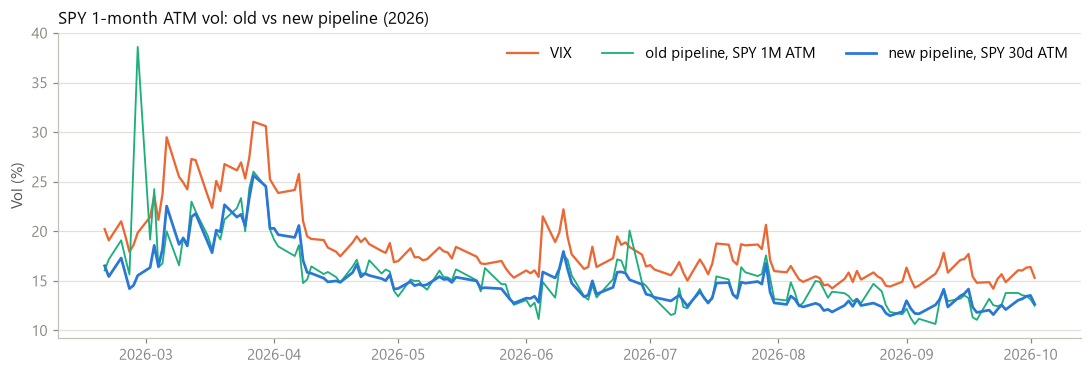

In [10]:
from src.surface.batch import load_surfaces
from src.surface.diagnostics import noise_stats

legacy = load_surfaces("SPY", surfaces_dir="data/_backup/surfaces_legacy_2026-10-02", builder=None)
old = pd.Series({pd.Timestamp(d): 100 * vs.atm_vol(1 / 12) for d, vs in legacy.items()}).sort_index()
new = live.set_index("date")["atm_30d"] * 100
vix = live.set_index("date")["mkt_vix"]
cmp = pd.DataFrame({
    "old pipeline (1M ATM)": {**noise_stats(old), **benchmark_against(old, vix)},
    "new pipeline (30d ATM)": {**noise_stats(new), **benchmark_against(new, vix)},
}).T
print(cmp[["sd_change", "lag1_autocorr", "max_abs_change", "change_corr"]].round(3))

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(vix.index, vix, color=T.series[1], lw=1.5, label="VIX")
ax.plot(old.index, old, color=T.series[2], lw=1.2, label="old pipeline, SPY 1M ATM")
ax.plot(new.index, new, color=T.series[0], lw=1.8, label="new pipeline, SPY 30d ATM")
style_axes(ax, "SPY 1-month ATM vol: old vs new pipeline (2026)", None, "Vol (%)")
ax.legend(frameon=False, ncol=3); plt.show()

The rebuild roughly halves the daily noise and removes the reversal pattern.
Agreement with VIX's daily moves rises from 0.44 to 0.96 (ATM) and 0.98
(variance swap).

## 7. Noise floors of the derived features

Treating each feature as a random walk plus independent measurement noise,
the noise standard deviation is `√(−ρ₁ · Var(Δ))`, where ρ₁ is the lag-1
autocorrelation of daily changes. The result is in vol points:

In [11]:
f = load_feature_table().sort_values(["ticker", "date"])
cols = ["atm_30d", "vs_30d", "rr25_30d", "bf25_30d", "rr25_91d", "bf25_91d"]

def noise(s):
    d = s.dropna().diff().dropna()
    return np.nan if len(d) < 20 else 100 * np.sqrt(max(-d.autocorr(), 0) * d.var())

floors = f.groupby("ticker")[cols].agg(noise).T
levels = f.groupby("ticker")[cols].agg(lambda s: 100 * s.abs().median()).T
print("Estimated daily measurement noise (vol pts):"); display(floors.round(2))
print("Noise as a share of the typical level:"); display((floors / levels).round(2))

Estimated daily measurement noise (vol pts):


ticker,AAPL,GLD,IWM,MSFT,QQQ,SPY,TSLA,XLF
atm_30d,0.47,0.00,0.45,0.00,0.52,0.48,0.00,0.49
vs_30d,0.50,0.00,0.56,0.00,0.59,0.59,0.16,1.03
rr25_30d,0.33,0.29,0.29,0.29,0.28,0.32,0.29,0.36
bf25_30d,0.06,0.03,0.04,0.08,0.04,0.03,0.09,0.14
rr25_91d,0.12,0.21,0.20,0.15,0.20,0.23,0.20,0.45
bf25_91d,0.03,0.05,0.03,0.03,0.03,0.02,0.06,0.15


Noise as a share of the typical level:


ticker,AAPL,GLD,IWM,MSFT,QQQ,SPY,TSLA,XLF
atm_30d,0.02,0.00,0.02,0.00,0.02,0.03,0.00,0.03
vs_30d,0.02,0.00,0.02,0.00,0.02,0.03,0.00,0.05
rr25_30d,0.15,0.19,0.07,0.22,0.05,0.08,0.22,0.12
bf25_30d,0.10,0.04,0.08,0.15,0.08,0.05,0.07,0.24
rr25_91d,0.04,0.14,0.05,0.09,0.03,0.05,0.19,0.12
bf25_91d,0.06,0.06,0.06,0.08,0.04,0.03,0.05,0.19


Butterflies look noisy by autocorrelation, but their absolute noise is a few
hundredths of a vol point, well inside a bid-ask spread. The only feature
where noise is a large share of the level is the 30-day risk reversal on
single stocks (15–20%). That is quote-level noise at the 25-delta strikes,
so prefer its 5-day changes, or smooth it.

## 8. The rejected alternative: a joint eSSVI fit

SSVI (Gatheral & Jacquier) ties all expiries together:
`w(k) = θ/2 · (1 + ρφk + √((φk + ρ)² + 1 − ρ²))`, with `φ(θ) = η / (θ^γ (1+θ)^(1−γ))`.
The eSSVI variant lets ρ vary by expiry. With two parameters per expiry plus
two shared, it was tested as a way to steady thin chains like XLF. Fitting
the same quotes with the same weights:

median fit error: eSSVI 0.89 pts vs per-expiry SVI 0.33 pts


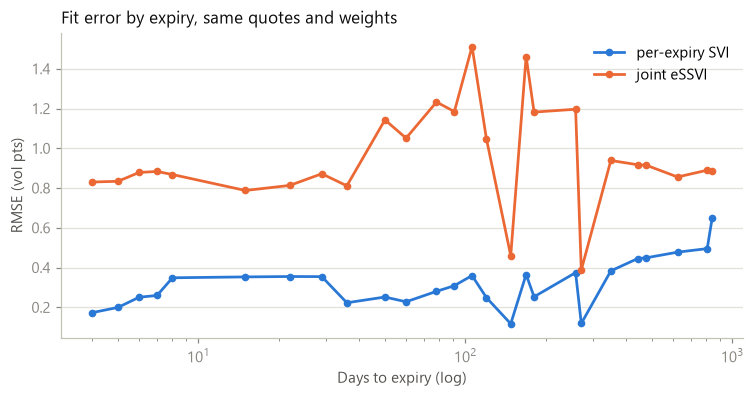

In [12]:
from scipy.optimize import least_squares

def essvi_w(k, theta, rho, eta, gamma):
    phi = eta / (theta ** gamma * (1 + theta) ** (1 - gamma))
    return 0.5 * theta * (1 + rho * phi * k + np.sqrt((phi * k + rho) ** 2 + 1 - rho ** 2))

groups = [(float(Tq), g.sort_values("k")) for Tq, g in quotes.groupby("T") if len(g) >= 6]
n = len(groups)
theta0 = np.maximum.accumulate([max(g.iloc[int(np.argmin(np.abs(g["k"])))]["iv"] ** 2 * Tq, 1e-6)
                                for Tq, g in groups])
x0 = np.concatenate([[1.0, 0.4], theta0, np.full(n, -0.5)])
lo = np.concatenate([[1e-3, 0.01], np.full(n, 1e-7), np.full(n, -0.999)])
hi = np.concatenate([[10.0, 0.99], np.full(n, 5.0), np.full(n, 0.999)])

def resid(x):
    out = []
    for j, (Tq, g) in enumerate(groups):
        w = np.maximum(essvi_w(g["k"].to_numpy(), x[2 + j], x[2 + n + j], x[0], x[1]), 1e-12)
        spread = np.maximum(g["spread_iv"].fillna(0.01).to_numpy(), 0.005)
        out.append((np.sqrt(w / Tq) - g["iv"].to_numpy()) / spread)
    return np.concatenate(out)

x = least_squares(resid, x0, bounds=(lo, hi), loss="soft_l1", f_scale=2.0, x_scale="jac").x
by_T = {round(f.T, 8): f for f in fits}
rows = []
for j, (Tq, g) in enumerate(groups):
    k, iv = g["k"].to_numpy(), g["iv"].to_numpy()
    e = np.sqrt(np.maximum(essvi_w(k, x[2 + j], x[2 + n + j], x[0], x[1]), 0) / Tq) - iv
    s = by_T.get(round(Tq, 8))
    rows.append({"days": round(365 * Tq), "eSSVI_rmse_pts": 100 * np.sqrt(np.mean(e ** 2)),
                 "SVI_rmse_pts": 100 * s.rmse_iv if s else np.nan})
ess = pd.DataFrame(rows)
print(f"median fit error: eSSVI {ess['eSSVI_rmse_pts'].median():.2f} pts vs "
      f"per-expiry SVI {ess['SVI_rmse_pts'].median():.2f} pts")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ess["days"], ess["SVI_rmse_pts"], color=T.series[0], marker="o", ms=4, label="per-expiry SVI")
ax.plot(ess["days"], ess["eSSVI_rmse_pts"], color=T.series[1], marker="o", ms=4, label="joint eSSVI")
ax.set_xscale("log")
style_axes(ax, "Fit error by expiry, same quotes and weights", "Days to expiry (log)", "RMSE (vol pts)")
ax.legend(frameon=False); plt.show()

eSSVI's error is 3–4× higher at every expiry. That is structural, not a
convergence problem: an SSVI slice has three degrees of freedom and ties
smile curvature to skew, which can't match SPY's smile. Across the live
corpus this moved the 30-day 25-delta risk reversal by about 2 vol points,
trading noise for a systematic bias. It was not adopted.

## Summary

- Surfaces are built **per expiry**, on **parity forwards**, from
  **OTM mid-price IVs**, with a **constrained, spread-weighted SVI** fit
  and **tangent wings**. Extrapolated cells are flagged and never used as
  features.
- Validated against VIX: **0.97–0.98 daily-change correlation** and a
  **0.3–0.4 vol-point** mean gap, over 2010–2023 (including March 2020)
  and 2026.
- Remaining noise is mostly far below bid-ask. The exception is the
  single-stock 30-day risk reversal; use its 5-day changes or smooth it.